In [1]:
import torch 
from ddw.utils.visualization import plot_tomo_slices

tomo0 = torch.load('tutorial/tutorial_project/subtomos/fitting_subtomos/subtomo0/0.pt').unsqueeze(0)


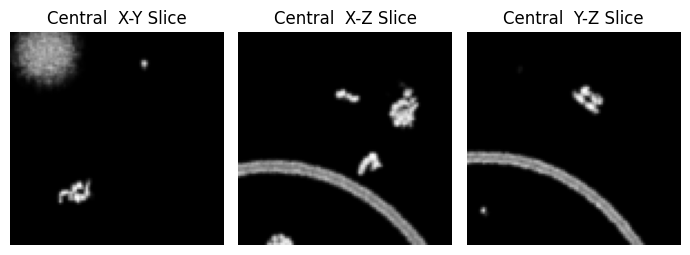

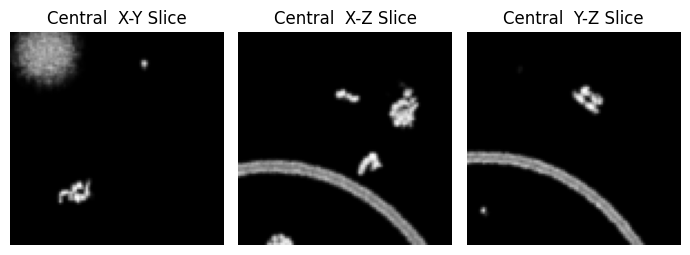

In [3]:
plot_tomo_slices(tomo0)

In [ ]:
from ddw.utils.unet import LitUnet3D
from torch.nn import functional as F


model_checkpoint_file = "tutorial/tutorial_project/logs/version_1/checkpoints/epoch/epoch=49.ckpt"
gpu = 0
device = "cpu" if gpu is None else f"cuda:{gpu}"
print(f"Loading model from {model_checkpoint_file}")
net = (
    LitUnet3D.load_from_checkpoint(model_checkpoint_file).to(device).eval()
)
rnd_normal = torch.randn([tomo0.shape[0], 1, 1, 1, 1], device=device)
sigma = (rnd_normal * 1.2 + -1.2).exp()
weight = (sigma ** 2 + 1 ** 2) / (sigma * 1) ** 2
y = tomo0.unsqueeze(1)
n = torch.randn_like(y) * sigma
D_yn = net(y + n, sigma)
loss = weight * F.smooth_l1_loss(D_yn, y, reduction="none")
print(loss)

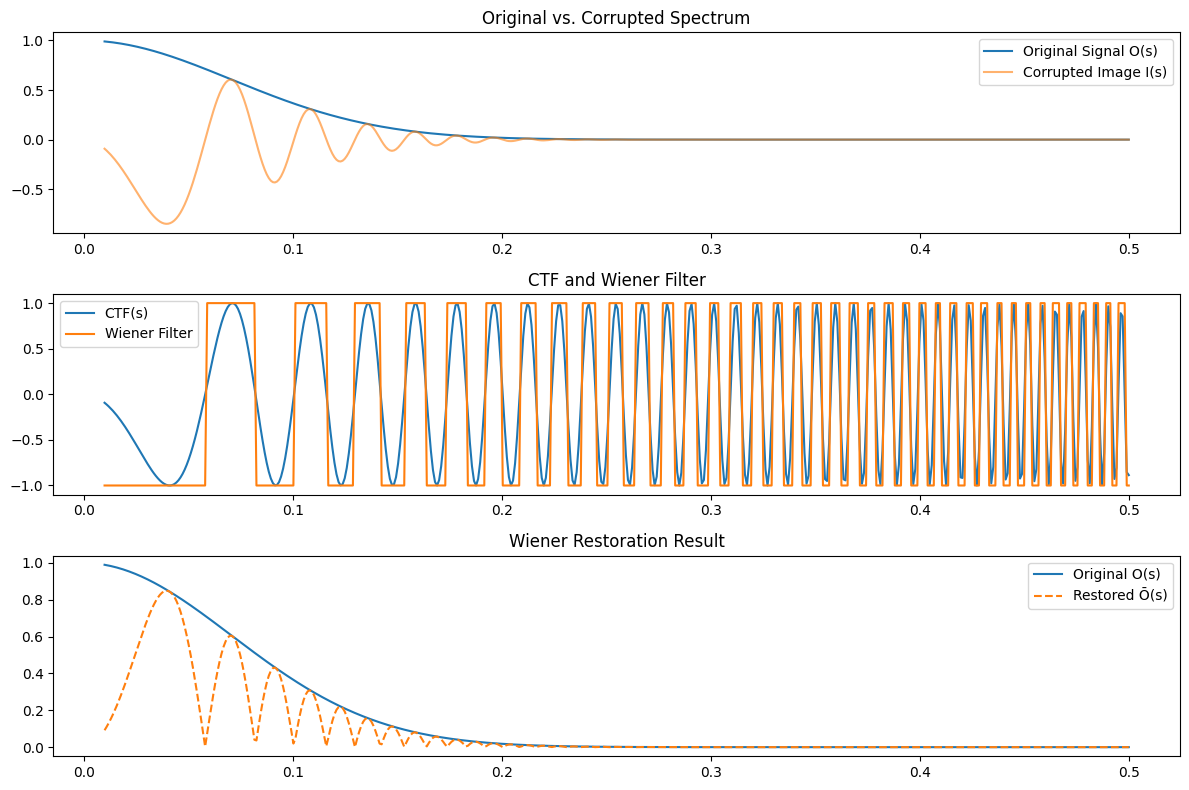

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. 设置空间频率范围
# -------------------------------
s = np.linspace(0.01, 0.5, 500)  # 空间频率 (1/Å)

# -------------------------------
# 2. 设置参数（模拟CTF曲线）
# -------------------------------
lam = 0.0197  # 电子波长（Å） - 对应300kV加速电压
defocus = 15000  # Å (15 µm underfocus)
Cs = 2.0e7       # 球差，Å (2 mm)

# CTF 相位函数
chi = np.pi * lam * defocus * s**2 + 0.5 * np.pi * Cs * lam**3 * s**4
CTF = -np.sin(chi)

# -------------------------------
# 3. 模拟真实信号 O(s)
# -------------------------------
O = np.exp(-s**2 / 0.01)  # 一个高斯频谱，模拟结构信号

# -------------------------------
# 4. 添加噪声形成 I(s)
# -------------------------------
np.random.seed(0)
noise = 0.0 * np.random.randn(len(s))  # 高斯白噪声
I = CTF * O + noise  # 观测图像频谱

# -------------------------------
# 5. 设置信噪比 SNR(s)
# -------------------------------
SNR = (O**2) / (0.2**2)  # 假设噪声方差为 0.2²

# -------------------------------
# 6. Wiener 滤波器 & 恢复
# -------------------------------
sign_filter = np.sign(CTF)
# Wiener_filter = CTF / (CTF**2 + 1 / SNR)
O_hat = sign_filter * I  # 恢复出的频谱

# -------------------------------
# 7. 可视化
# -------------------------------
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(s, O, label='Original Signal O(s)')
plt.plot(s, I, label='Corrupted Image I(s)', alpha=0.6)
plt.title('Original vs. Corrupted Spectrum')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(s, CTF, label='CTF(s)')
plt.plot(s, sign_filter, label='Wiener Filter')
plt.title('CTF and Wiener Filter')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(s, O, label='Original O(s)')
plt.plot(s, O_hat, label='Restored Ō(s)', linestyle='--')
plt.title('Wiener Restoration Result')
plt.legend()

plt.tight_layout()
plt.show()


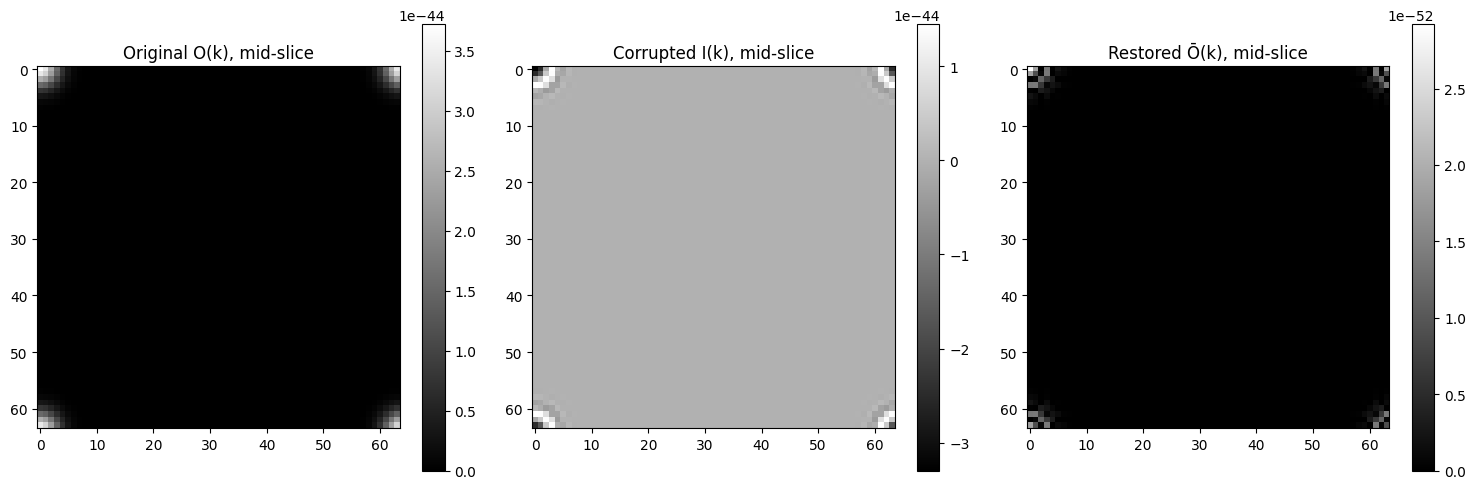

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 1. 创建三维空间频率网格
# --------------------------
N = 64  # 网格大小（64³）
freq = np.fft.fftfreq(N, d=1.0)
kx, ky, kz = np.meshgrid(freq, freq, freq, indexing='ij')
k = np.sqrt(kx**2 + ky**2 + kz**2)  # 频率模

# --------------------------
# 2. 构造原始频谱 O(k)
# --------------------------
O = np.exp(- (k**2) / (0.05**2))  # 类似于高斯球体的结构频谱

# --------------------------
# 3. 构造CTF(k)
# --------------------------
lam = 0.0197  # 300kV电子波长 (Å)
defocus = 15000  # Å
Cs = 2e7         # Å

# 相位函数（简化近轴公式）
chi = np.pi * lam * defocus * k**2 + 0.5 * np.pi * Cs * lam**3 * k**4
CTF = -np.sin(chi)

# --------------------------
# 4. 模拟腐败频谱 I(k)
# --------------------------
np.random.seed(42)
noise_level = 0.0
noise = noise_level * np.random.randn(*k.shape)
I = CTF * O + noise

# --------------------------
# 5. 计算 SNR(k)
# --------------------------
SNR = (O**2) / (noise_level**2 + 1e-8)

# --------------------------
# 6. Wiener 滤波器 & 复原
# --------------------------
Wiener_filter = CTF / (CTF**2 + 1 / (SNR + 1e-8))
O_hat = Wiener_filter * I

# --------------------------
# 7. 可视化某一横截面（中间切片）
# --------------------------
import matplotlib.pyplot as plt

slice_index = N // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(O[:, :, slice_index], cmap='gray')
plt.title("Original O(k), mid-slice")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(I[:, :, slice_index], cmap='gray')
plt.title("Corrupted I(k), mid-slice")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(O_hat[:, :, slice_index], cmap='gray')
plt.title("Restored Ō(k), mid-slice")
plt.colorbar()

plt.tight_layout()
plt.show()
